In [2]:
%%capture
%run parse_data.ipynb
%run descriptive.ipynb
%run classical.ipynb
%run machine.ipynb

In [39]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib import gridspec
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn import tree, preprocessing
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression, RidgeCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


def display_title(s, pref='Figure', num=1, center=False):
    ctag = 'center' if center else 'p'
    s    = f'<{ctag}><span style="font-size: 1.2em;"><b>{pref} {num}</b>: {s}</span></{ctag}>'
    if pref=='Figure':
        s = f'<br>{s}'
    else:
        s = f'<br>{s}'
    display( Markdown(s) )

The first step in preprocessing the data is normalization. Normalizing data not only helps with removing bias from the model but also helps with regularization, which both KNN Regression and Logistic Regression benefits from.

From the box plots of in descriptive notebook, we can see that Happiness has indications of outliers. However, because the data belongs to Likert scale, it can represent true opinion of some respondents and not considered a mistake. Therefore, I will use min-max normalization with and without removing outliers to see which method performs better.

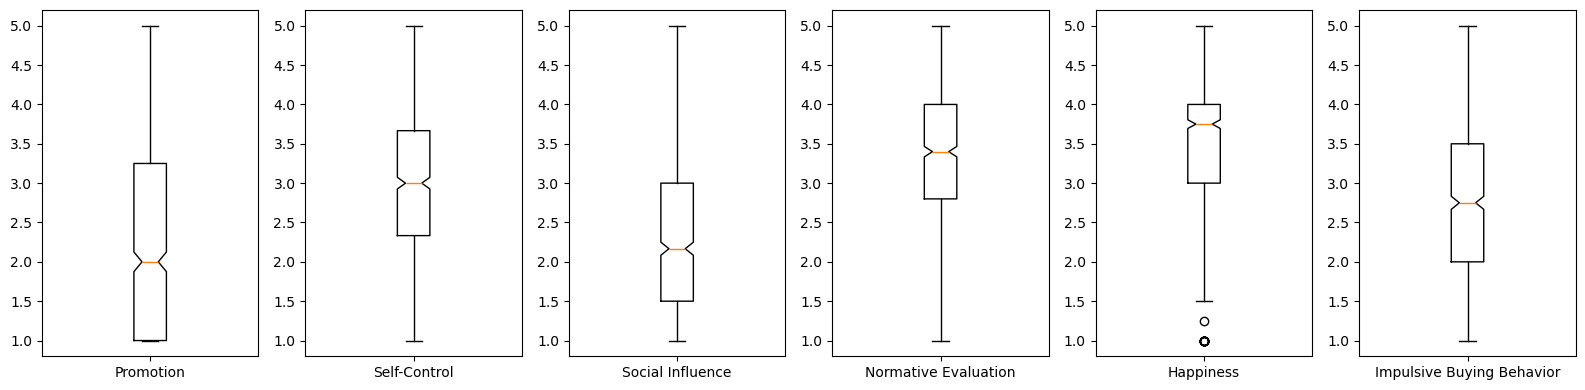

<br><p><span style="font-size: 1.2em;"><b>Figure 1</b>: Box plot for distribution visualization of variables</span></p>

In [4]:
def box_plot(num = 1):
    fig, axs = plt.subplots(1, 6, figsize = (16,4), tight_layout = True)
    axs[0].boxplot( df['P'], tick_labels = ['Promotion'], notch = True)
    axs[1].boxplot( df['SC'], tick_labels = ['Self-Control'], notch = True)
    axs[2].boxplot( df['SI'], tick_labels = ['Social Influence'], notch = True)
    axs[3].boxplot( df['NE'], tick_labels = ['Normative Evaluation'], notch = True)
    axs[4].boxplot( df['H'], tick_labels = ['Happiness'], notch = True)
    axs[5].boxplot( df['IBB'], tick_labels = ['Impulsive Buying Behavior'], notch = True ) 

    plt.show()

    display_title("Box plot for distribution visualization of variables", pref='Figure', num=1)

box_plot(num = 1)

In [5]:
def omit(col):
    q1,q3=np.percentile(col, [25,75])
    iqr = q3 - q1
    lower_bound = q1-1.5*iqr
    upper_bound = q3 + 1.5*iqr
    return lower_bound, upper_bound

In [6]:
lb, up = omit(df['H'])
df['H_cleaned'] = np.clip(df['H'], lb, up)

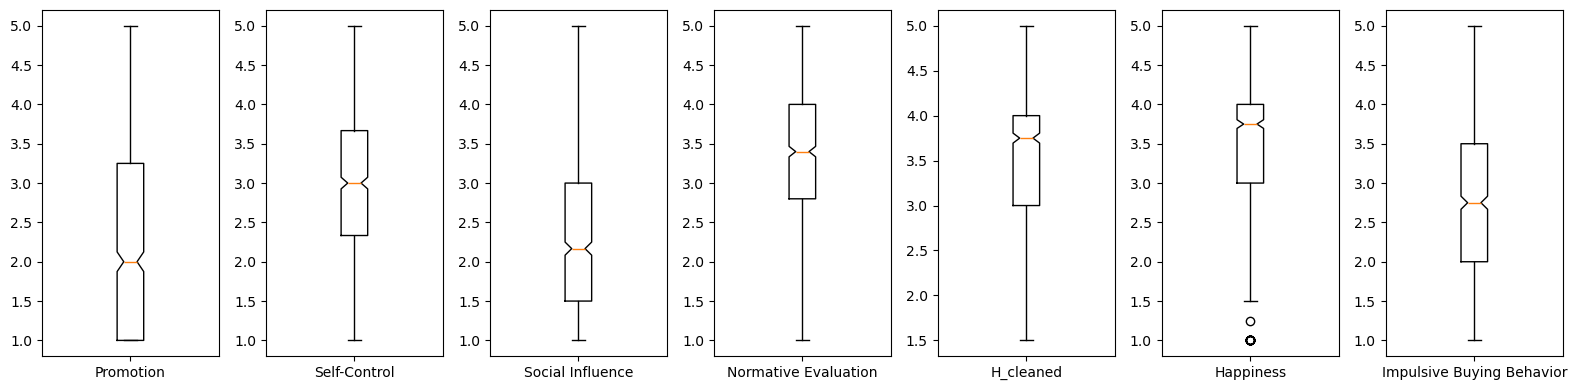

In [7]:
def box_plot(num = 0):
    fig, axs = plt.subplots(1, 7, figsize = (16,4), tight_layout = True)
    axs[0].boxplot( df['P'], tick_labels = ['Promotion'], notch = True)
    axs[1].boxplot( df['SC'], tick_labels = ['Self-Control'], notch = True)
    axs[2].boxplot( df['SI'], tick_labels = ['Social Influence'], notch = True)
    axs[3].boxplot( df['NE'], tick_labels = ['Normative Evaluation'], notch = True)
    axs[4].boxplot( df['H_cleaned'], tick_labels = ['H_cleaned'], notch = True)
    axs[5].boxplot( df['H'], tick_labels = ['Happiness'], notch = True)
    axs[6].boxplot( df['IBB'], tick_labels = ['Impulsive Buying Behavior'], notch = True ) 

    plt.show()

box_plot(num = 0)

First, let's normalize the data

In [8]:
scaler = MinMaxScaler()

normalized_with_outliers = scaler.fit_transform(df[['P', 'SI', 'SC', 'H', 'NE', 'IBB']])
normalized_no_outliers = scaler.fit_transform( df[['P', 'SI', 'SC', 'H_cleaned', 'NE', 'IBB']])

Let's first use the new normalized dataset with the Logistic Regression model.

To further improve the Logistic Regression model, I will try with L1 and L2 regularizations.

In [9]:
X_new_outlier = df[['P', 'SI', 'SC', 'H', 'NE', 'IBB']]
X_new_no_outlier = df[['P', 'SI', 'SC', 'H_cleaned', 'NE', 'IBB']]

In [10]:
LG_model_L1 = LogisticRegression(penalty='l1', random_state=42, solver='liblinear', class_weight='balanced')
LG_model_L2 = LogisticRegression(penalty='l2', random_state=42, class_weight='balanced')

Original score of Logistic Regression model

In [11]:
print(f"The highest accuracy score: {max_LG_acc:.2f}") 
print(f"The highest precision score: {max_LG_pre:.2f}")
print(f"The highest recall score: {max_LG_rec:.2f}")
print(f"The average accuracy for the model: {np.mean(LG_acc):.2f}")
print(f"The average precision of the model: {np.mean(LG_pre):.2f}")
print(f"The average recall of the model: {np.mean(LG_rec):.2f}")

The highest accuracy score: 0.86
The highest precision score: 0.68
The highest recall score: 0.87
The average accuracy for the model: 0.73
The average precision of the model: 0.48
The average recall of the model: 0.73


Score for L1 regularized model

In [12]:
LG_acc_L1_outlier = cross_val_score(LG_model_L1, X_new_outlier, y, cv = kf, scoring='accuracy')
LG_pre_L1_outlier = cross_val_score(LG_model_L1, X_new_outlier, y, cv = kf, scoring='precision')
LG_rec_L1_outlier = cross_val_score(LG_model_L1, X_new_outlier, y, cv = kf, scoring='recall')

LG_acc_L1_no_outliers = cross_val_score(LG_model_L1, X_new_no_outlier, y, cv = kf, scoring='accuracy')
LG_pre_L1_no_outliers = cross_val_score(LG_model_L1, X_new_no_outlier, y, cv = kf, scoring='precision')
LG_rec_L1_no_outliers = cross_val_score(LG_model_L1, X_new_no_outlier, y, cv = kf, scoring='recall')

def comparison_LG1():
    table = pd.DataFrame({("Accuracy", "Average"): [np.mean(LG_acc_L1_outlier), np.mean(LG_acc_L1_no_outliers)],
                        ("Accuracy", "Max"): [np.max(LG_acc_L1_outlier), np.max(LG_acc_L1_no_outliers)],
                        ("Precision", "Average"): [np.mean(LG_pre_L1_outlier), np.mean(LG_pre_L1_no_outliers)],
                        ("Precision", "Max"): [np.max(LG_pre_L1_outlier), np.max(LG_pre_L1_no_outliers)],
                        ("Recall", "Average"): [np.mean(LG_rec_L1_outlier), np.mean(LG_rec_L1_no_outliers)],
                        ("Recall", "Max"): [np.max(LG_rec_L1_outlier), np.max(LG_rec_L1_no_outliers)],}, index=["With Outliers", "No Outliers"])
    table = table.round(2)
    display(table)

comparison_LG1()

Accuracy       Precision        Recall      
               Average   Max   Average   Max Average   Max
With Outliers     0.73  0.85      0.49  0.65    0.75  0.94
No Outliers       0.73  0.85      0.49  0.65    0.75  0.94

Score for L2 regularized model:

In [13]:
LG_acc_L2_outlier = cross_val_score(LG_model_L2, X_new_outlier, y, cv = kf, scoring='accuracy')
LG_pre_L2_outlier = cross_val_score(LG_model_L2, X_new_outlier, y, cv = kf, scoring='precision')
LG_rec_L2_outlier = cross_val_score(LG_model_L2, X_new_outlier, y, cv = kf, scoring='recall')

LG_acc_L2_no_outliers = cross_val_score(LG_model_L2, X_new_no_outlier, y, cv = kf, scoring='accuracy')
LG_pre_L2_no_outliers = cross_val_score(LG_model_L2, X_new_no_outlier, y, cv = kf, scoring='precision')
LG_rec_L2_no_outliers = cross_val_score(LG_model_L2, X_new_no_outlier, y, cv = kf, scoring='recall')

def comparison_LG2():
    table = pd.DataFrame({("Accuracy", "Average"): [np.mean(LG_acc_L2_outlier), np.mean(LG_acc_L2_no_outliers)],
                        ("Accuracy", "Max"): [np.max(LG_acc_L2_outlier), np.max(LG_acc_L2_no_outliers)],
                        ("Precision", "Average"): [np.mean(LG_pre_L2_outlier), np.mean(LG_pre_L2_no_outliers)],
                        ("Precision", "Max"): [np.max(LG_pre_L2_outlier), np.max(LG_pre_L2_no_outliers)],
                        ("Recall", "Average"): [np.mean(LG_rec_L2_outlier), np.mean(LG_rec_L2_no_outliers)],
                        ("Recall", "Max"): [np.max(LG_rec_L2_outlier), np.max(LG_rec_L2_no_outliers)],}, index=["With Outliers", "No Outliers"])
    table = table.round(2)
    display(table)

comparison_LG2()

Accuracy       Precision        Recall      
               Average   Max   Average   Max Average   Max
With Outliers     0.73  0.86      0.48  0.68    0.73  0.87
No Outliers       0.73  0.86      0.48  0.68    0.73  0.87

From the results of both models, we can deduce following conclusions:
- There is no difference in predictive scores in all models, whether outliers are included or not. Therefore, to preserve the diversity of opinion in Likert scale, we will choose the dataset with outliers
- The L1 regularlized model has an increase of 2% in Average Recall and a 7% increase in Max Recall, while sacrificing only 1% in Max Accuracy and 3% in Max Precision (Not a core metric of the model)

The L1 Regularlized Logistic Regression model will be chosen as the final model to report

<br><p><span style="font-size: 1.2em;"><b>Figure 1</b>: Logistic Regression model's performance in predicting User Status</span></p>

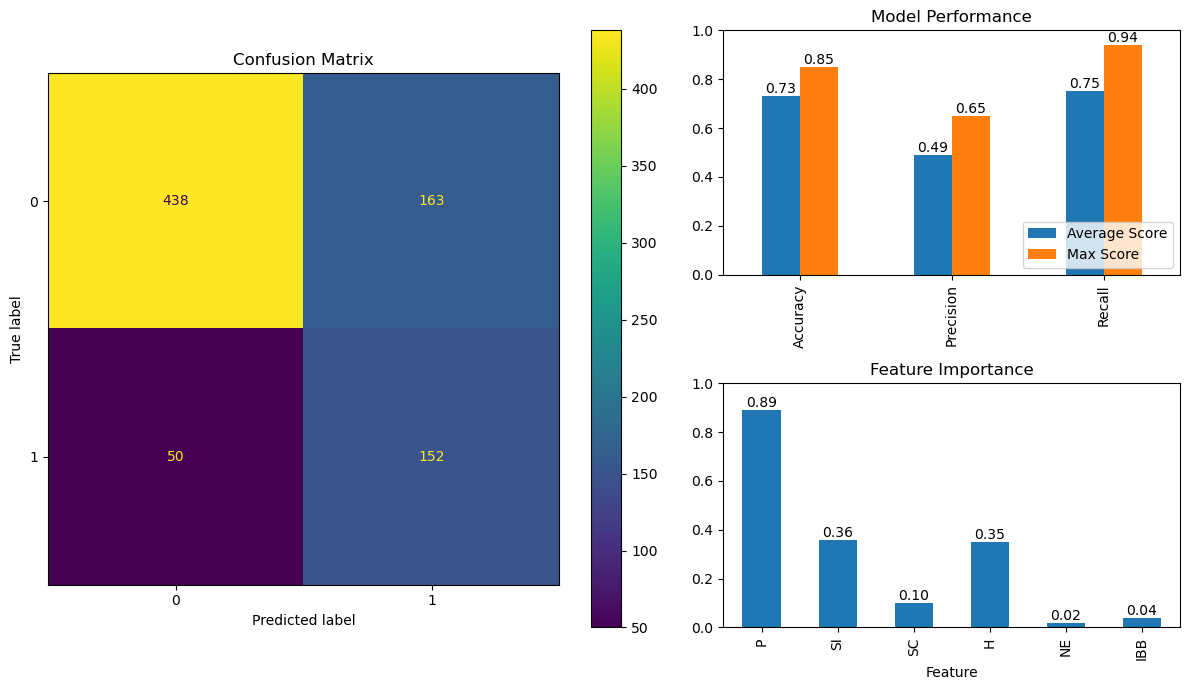

In [14]:
def L1_LG_results():
    # scores for model
    table = pd.DataFrame(index=["Accuracy", "Precision", "Recall"])
    table["Average Score"] = [np.mean(LG_acc_L1_outlier), np.mean(LG_pre_L1_outlier), np.mean(LG_rec_L1_outlier)]
    table["Max Score"] = [np.max(LG_acc_L1_outlier), np.max(LG_pre_L1_outlier), np.max(LG_rec_L1_outlier)]
    table = table.round(2)

    # feature coefficient table
    LG_model_L1.fit(X_new_outlier, y)
    coefficients = LG_model_L1.coef_[0]
    abs_coefficients = abs(LG_model_L1.coef_[0])
    feature_coefficient = pd.DataFrame({'Feature': X_new_outlier.columns, 'Coefficient': coefficients, 'Absolute Coefficient': abs_coefficients})
    feature_coefficient = feature_coefficient.round(2)

    # confusion matrix
    y_predict = cross_val_predict(LG_model_L1, X_new_outlier, y, cv = kf)
    cm = confusion_matrix(y, y_predict)
    model_cm_visual = ConfusionMatrixDisplay(cm)

    # create a plot with gridspec to plot all tables and the confusion matrix
    fig = plt.figure(figsize=(12, 7))
    gs = gridspec.GridSpec(2, 2, width_ratios=[1.4, 1])
    
    ax_cm = fig.add_subplot(gs[:,0])
    model_cm_visual.plot(ax=ax_cm)
    ax_cm.set_title("Confusion Matrix")

    ax_score = fig.add_subplot(gs[0,1])
    table.plot(kind="bar", ax=ax_score)
    ax_score.set_title("Model Performance")
    ax_score.legend(loc="lower right")
    ax_score.set_ylim(0, 1)
    for container in ax_score.containers:
        ax_score.bar_label(container, fmt="%.2f")

    ax_feat = fig.add_subplot(gs[1, 1])
    feature_coefficient.set_index("Feature")["Absolute Coefficient"].plot(kind="bar", ax=ax_feat)
    ax_feat.set_ylim(0, 1)
    ax_feat.set_title("Feature Importance")
    for value in ax_feat.containers:
        ax_feat.bar_label(value, fmt="%.2f")
    
    display_title("Logistic Regression model's performance in predicting User Status", pref='Figure', num=1)
    plt.tight_layout()
    plt.show()

L1_LG_results()

---

Let's move on to the KNN Regressor model! 

To improve the results of the model, I will try feature selection to select the suitable subset that maximizes predicitve and interpretability of the model

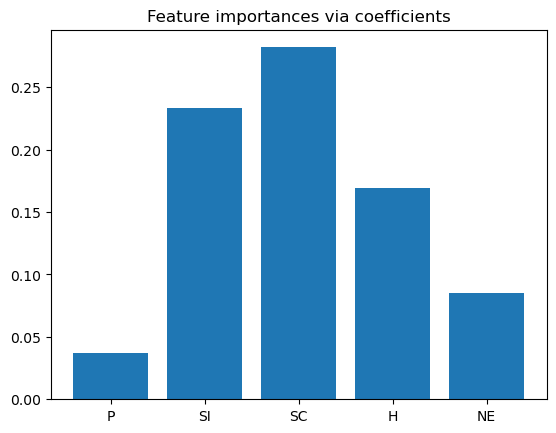

The selected features via coefficients are: ['P' 'SI' 'H']


In [ ]:
# Select variables 
X_reg_outlier = df[['P', 'SI', 'SC', 'H', 'NE']]
y_reg = df['IBB']

ridge = RidgeCV(alphas=0.1).fit(X_reg_outlier, y_reg)
importance = np.abs(ridge.coef_)
feature_names = np.array(X_reg_outlier.columns)
plt.bar(height=importance, x=feature_names)
plt.title("Feature importances via coefficients")
plt.show()

threshold = 0.02
sfm = SelectFromModel(ridge, threshold=threshold).fit(X_reg_outlier, y)
print(f"The selected features via coefficients are: {feature_names[sfm.get_support()]}")

We will try to implement KNN Regressor model with the selected features

In [16]:
# Dataframe with selected features
X_reg_selected = df[['P', 'SI', 'H']]

k_mod_new = KNeighborsRegressor(n_neighbors=58, weights='distance')         # during the process of tuning, I found out that by setting the neighbors to 58 returns the best result
k_rsme_new = cross_val_score(k_mod_new, X_reg_selected, y_reg, cv = kf, scoring = 'neg_root_mean_squared_error')
k_r2_new = cross_val_score(k_mod_new, X_reg_selected, y_reg, cv = kf, scoring = 'r2')

trained_kneighbor_new = k_mod_new.fit(X_reg_selected, y_reg)

print(f"Root Mean Squared Error (RMSE) of KNN Regressor model: {np.mean(-k_rsme_new):.4f}")
print(f"Coefficient of Determination (R²) of KNN Regressor model: {np.mean(k_r2_new):.4f}")

Root Mean Squared Error (RMSE) of KNN Regressor model: 0.8344
Coefficient of Determination (R²) of KNN Regressor model: 0.0769


We can see that feature selection made the result of the model worse, so we will revert to the orginal model and tune the hyperparameters inside it instead

In [37]:
param_grid = {'n_neighbors': [30, 40, 50, 58, 70, 90, 120], 'weights': ['distance', 'uniform'], 'p': [1, 2], 'metric': ['manhattan', 'cosine', 'euclidean']}

k_try = KNeighborsRegressor()
grid_search_rmse = GridSearchCV(k_try, param_grid, cv = kf, scoring = 'neg_root_mean_squared_error', n_jobs=-1)
grid_search_r2 = GridSearchCV(k_try, param_grid, cv = kf, scoring = 'r2', n_jobs=-1)
grid_search_rmse.fit(X_reg_outlier, y_reg)
grid_search_r2.fit(X_reg_outlier, y_reg)
print("Best params:", grid_search_rmse.best_params_)
print("Best CV RMSE:", -grid_search_rmse.best_score_)
print("Best R2 score", grid_search_r2.best_score_)

Best params: {'metric': 'manhattan', 'n_neighbors': 70, 'p': 1, 'weights': 'distance'}
Best CV RMSE: 0.7369536674698293
Best R2 score 0.2850510425368048


There is a slight decrease of 0.6% in RMSE score and a slight increase of 0.5% increase in R2 score. While tuning the hyperparameters yield better results, the change is still trivial. We will try to use PCA to reduce dimensionality to see if there is a more notable increase.



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV

pipe = Pipeline([('scaler', MinMaxScaler()),
                 ('pca', PCA()),
                 ('knn', KNeighborsRegressor())])
params = {'pca__n_components': [3, 4, 5, None], 'knn__n_neighbors':  [40, 50, 58, 60, 70, 80, 90, 100], 
          'knn__weights':      ['distance', 'uniform'], 'knn__p':[1, 2]}
gs_pca = GridSearchCV(estimator=pipe, param_grid=params, cv = kf, scoring = 'neg_root_mean_squared_error')
gs_pca.fit(X_reg_outlier, y_reg)

print("Best parameters:", gs_pca.best_params_)
print("Best CV RMSE:", -gs_pca.best_score_)

Best parameters: {'knn__n_neighbors': 50, 'knn__p': 2, 'knn__weights': 'distance', 'pca__n_components': 5}
Best CV RMSE: 0.7373137414868319


c:\Users\20tod\anaconda3\Lib\site-packages\numpy\ma\core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


The performance is not better for PCA.

Given the characteristics of Likert Scale data, we will switch to a new model: RandomForestRegressor. The model is said to be able handle weak signals and data that suffer from multicollinearity like that of our dataset, so let's try using it to see if it performs better.

In [50]:
from scipy.stats import randint

RFregressor = RandomForestRegressor(random_state=42)

param_rf = {
    'n_estimators': randint(50, 120),
    'max_depth': randint(5,20),
    'min_samples_split': randint(2,20),
    'min_samples_leaf': randint(2,20),
    'oob_score': [True, False]}

RF_rmse = RandomizedSearchCV(estimator=RFregressor, n_iter=30, param_distributions=param_rf, cv = kf, scoring = 'neg_root_mean_squared_error')
RF_R2 = RandomizedSearchCV(estimator=RFregressor, n_iter=30, param_distributions=param_rf, cv = kf, scoring = 'r2')

RF_rmse.fit(X_reg_outlier, y_reg)
RF_R2.fit(X_reg_outlier, y_reg)

print("Best parameters:", RF_rmse.best_params_)
print("Best CV RMSE:", -RF_rmse.best_score_)
print("Best CV R2:", RF_R2.best_score_)

Best parameters: {'max_depth': 16, 'min_samples_leaf': 17, 'min_samples_split': 10, 'n_estimators': 75, 'oob_score': False}
Best CV RMSE: 0.7250739106057734
Best CV R2: 0.3062561331832617


We can see that the Random Forest Regressor model performed better than the KNN Regressor model, so we will choose the RFR model to be our final model!

Let's now visualize the model for reporting

In [60]:
RFregressor_optimized = RandomForestRegressor(max_depth=16, min_samples_leaf=17, min_samples_split=10, n_estimators=75, oob_score=False, random_state=42)

trained_RFregressor = RFregressor_optimized.fit(X_reg_outlier, y_reg)

features_rf = X_reg_outlier.columns.tolist()

<br><p><span style="font-size: 1.2em;"><b>Figure 2</b>: Random Forest Regressor model's performance in predicting Impulsive Buying Behavior score</span></p>

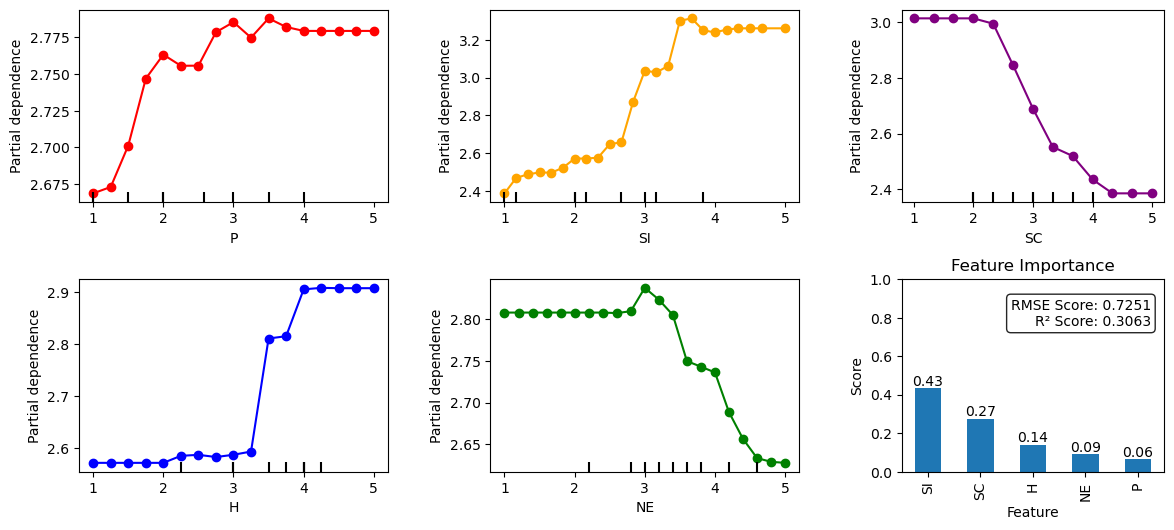

In [136]:
from sklearn.inspection import PartialDependenceDisplay

def RandomForestRegressor_results():
    # most important feature table
    importances = trained_RFregressor.feature_importances_
    feature_importance_rf = pd.DataFrame({'Feature': features_rf, 'Importance': importances})
    feature_importance_rf = feature_importance_rf.sort_values(by='Importance', ascending = False)

    # Relevant results of the model
    RF_model_result = pd.DataFrame(index=['RMSE', 'R² Score'])
    RF_model_result['Scores'] = [-RF_rmse.best_score_, RF_R2.best_score_]
    RF_model_result = RF_model_result.round(4)

    # create a plot with gridspec to plot all tables and plots of the model
    fig_rf = plt.figure(figsize=(14, 6))
    gs_rf = gridspec.GridSpec(2, 3, width_ratios=[2, 2, 1.7], height_ratios=[1,1], wspace=0.35, hspace=0.4)
    
    for i, feature_idx in enumerate(range(5)):
        row = (i//3)
        col = i % 3
        colors = ['red', 'orange', 'purple', 'blue', 'green']
        ax_plot_rf = fig_rf.add_subplot(gs_rf[row,col])
        PartialDependenceDisplay.from_estimator(estimator=trained_RFregressor, X=X_reg_outlier, features=[feature_idx],
                                                feature_names=features_rf, kind='average', ax=ax_plot_rf,
                                                line_kw={'color': colors[i], 'marker': 'o'})
        ax_plot_rf.set_xlabel(f"{feature_importance_rf.columns}")
        ax_plot_rf.set_ylim(2, 4)
        ax_plot_rf.set_ylabel("Predicted IBB score")

    # top features plot
    ax_feat = fig_rf.add_subplot(gs_rf[1,2])
    feature_importance_rf.set_index("Feature")["Importance"].plot(kind="bar", ax=ax_feat)
    ax_feat.set_ylim(0, 1)
    ax_feat.set_title("Feature Importance")
    text = (f"RMSE Score: {RF_model_result.loc['RMSE', 'Scores']:.4f}\n"
            f"R² Score: {RF_model_result.loc["R² Score", "Scores"]:.4f}")
    ax_feat.text(0.95, 0.9, text, transform = ax_feat.transAxes, fontsize = 10,
                 ha = 'right', va = 'top', bbox = dict(boxstyle='round', facecolor='white', alpha=0.85))
    ax_feat.set_ylabel("Score")
    for value in ax_feat.containers:
        ax_feat.bar_label(value, fmt="%.2f")
    
    display_title("Random Forest Regressor model's performance in predicting Impulsive Buying Behavior score", pref='Figure', num=2)
    plt.show()

RandomForestRegressor_results()